**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Mónica María Ramírez Mejía
*   MATRÍCULA: A01797493


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [812]:
# Importa las librerías necesarias

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [813]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia y Analitica de Datos/Tareas/Semana2"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [814]:
import pandas as pd
# importar dataframe
weather_df = pd.read_csv('cleaned_weather.csv')

In [815]:
# dimensionalidad dataframe
weather_df.shape

(52696, 13)

In [816]:
# indicadores de columnas
weather_df.columns

Index(['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='object')

In [817]:
# renombrar columnas
weather_df.columns = ['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']

In [818]:
# mostrar los primeros 5
weather_df.head(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [819]:
# mostrar los ultimos 5
weather_df.tail(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [820]:
# valores faltantes
weather_df.isna().sum()

,0
medicion,0
presion_atmosferica,0
temperatura_celsius,0
temperatura_kelvin,0
humedad_relativa,0
presion_vapor,0
humedad_especifica,0
concentracion_vapor,0
densidad_aire,0
velocidad_viento,0


2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime.
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`.

In [821]:
# tipo de datos
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   medicion             52696 non-null  object 
 1   presion_atmosferica  52696 non-null  float64
 2   temperatura_celsius  52696 non-null  float64
 3   temperatura_kelvin   52696 non-null  float64
 4   humedad_relativa     52696 non-null  float64
 5   presion_vapor        52696 non-null  float64
 6   humedad_especifica   52696 non-null  float64
 7   concentracion_vapor  52696 non-null  float64
 8   densidad_aire        52696 non-null  float64
 9   velocidad_viento     52696 non-null  float64
 10  direccion_viento     52696 non-null  float64
 11  precipitacion_total  52696 non-null  float64
 12  duracion_lluvia      52696 non-null  int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 5.2+ MB


In [822]:
# cambiar el tipo de la columna
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'])

/tmp/ipython-input-4047178297.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_df['medicion'] = pd.to_datetime(weather_df['medicion'])


In [823]:
# separar columnas en fecha y hora
weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time

In [824]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   medicion             52696 non-null  datetime64[ns]
 1   presion_atmosferica  52696 non-null  float64       
 2   temperatura_celsius  52696 non-null  float64       
 3   temperatura_kelvin   52696 non-null  float64       
 4   humedad_relativa     52696 non-null  float64       
 5   presion_vapor        52696 non-null  float64       
 6   humedad_especifica   52696 non-null  float64       
 7   concentracion_vapor  52696 non-null  float64       
 8   densidad_aire        52696 non-null  float64       
 9   velocidad_viento     52696 non-null  float64       
 10  direccion_viento     52696 non-null  float64       
 11  precipitacion_total  52696 non-null  float64       
 12  duracion_lluvia      52696 non-null  int64         
 13  fecha                52696 non-

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [825]:
# valores unicos
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


In [826]:
# identificar la medicion duplicada
weather_df['medicion'].value_counts()

,count
medicion,
2020-12-05 06:00:00,2
2020-08-31 23:10:00,1
2020-08-31 23:20:00,1
2020-08-31 23:30:00,1
2020-08-31 23:40:00,1
...,...
2020-02-05 00:00:00,1
2020-02-05 00:10:00,1
2020-02-05 00:20:00,1


In [827]:
# identificar fila de la medicion duplicada
weather_df.query("medicion == '2020-12-05 06:00:00'")

/tmp/ipython-input-3050764360.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  weather_df.query("medicion == '2020-12-05 06:00:00'")


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-12-05 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-12-05,06:00:00
19044,2020-12-05 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-12-05,06:00:00


In [828]:
# eliminar duplicado de medicion
weather_df.drop(index = 19043, inplace= True)

In [829]:
# dimensionalidad nueva
# comprobacion propia
weather_df.shape

(52695, 15)

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [830]:
# valores unicos, despues de remover duplicados
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


            ¿Por qué son 144 horas diferentes? Porque las mediciones se realizaron en varios intervalos de tiempo de cada dia

In [831]:
# identificar las fechas en las que faltan mediciones
BM= weather_df['fecha'].value_counts() < 144
BM [BM]

,count
fecha,
2020-01-01,True
2020-05-29,True
2021-01-01,True


In [832]:
# eliminar registros que no correspondan al año 2020
weather_df.query("medicion >= '2021-01-01 00:00:00'")

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
52695,2021-01-01,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0,2021-01-01,00:00:00


In [833]:
weather_df.drop(index = 52695, inplace= True)

In [834]:
# eliminamos columna medicion
weather_df.drop(columns = 'medicion', inplace = True)

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [835]:
# nuevo dataframe con valor maximo de las mediciones por dia
indicadores_diarios = weather_df.groupby('fecha').max()

In [836]:
# elimino la columna hora, porque no muestra informacion relevante (se repite el maximo de hora) y verifico dimensionalidad
indicadores_diarios.drop(columns = 'hora', inplace = True)
indicadores_diarios.shape

(366, 12)

In [837]:
indicadores_diarios.head(5)

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
fecha,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
2020-01-02,983.52,13.11,288.13,87.8,11.61,7.43,11.89,1208.07,8.70,345.4,0.2,600
2020-01-03,973.09,10.88,286.46,79.6,7.22,4.63,7.43,1215.51,10.56,240.5,0.1,170
2020-01-04,1000.05,8.91,282.79,80.5,3.84,2.40,3.85,1301.02,3.12,346.3,0.0,0
2020-01-05,977.99,14.20,289.36,86.5,9.85,6.30,10.09,1207.03,9.04,238.3,0.5,600


In [838]:
# ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
weather_df.loc[weather_df['precipitacion_total'].idxmax()].to_frame().T

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
24142,987.18,19.55,293.78,69.66,15.87,10.06,16.07,1167.77,4.18,11.34,11.2,600,2020-06-16,17:10:00


R// 11.2

In [839]:
# ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
weather_df.loc[weather_df['velocidad_viento'].nlargest(3).index]

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
5759,968.56,12.41,288.19,56.09,8.09,5.21,8.36,1177.79,13.77,208.4,0.0,0,2020-10-02,00:00:00
6758,978.47,17.16,292.13,36.10,7.08,4.51,7.23,1170.88,13.00,208.1,0.0,0,2020-02-16,22:30:00
5764,967.03,12.33,288.24,59.63,8.56,5.52,8.85,1176.04,12.99,205.0,0.0,0,2020-10-02,00:50:00


In [840]:
# ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
((weather_df['humedad_relativa'] > 90) & (weather_df['temperatura_celsius'] > 30)).sum()

np.int64(0)

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [841]:
# estadisticas descriptivas de indicadores_diarios
indicadores_diarios.describe()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


In [842]:
# desviacion estandar de concentracion de vapor
indicadores_diarios['concentracion_vapor'].std()

4.573267035838974

In [843]:
# mediana de presion atmosferica
indicadores_diarios['presion_atmosferica'].median()

993.3

In [844]:
# cuartil 3 de duracion de lluvia
indicadores_diarios['duracion_lluvia'].quantile(0.75)

np.float64(600.0)

* ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
La desviación estandar es de 4.573267 y esto indica que los datos se alejan en esa cantidad de la media (11.539180).

* ¿Cuál es la mediana de la presión atmosférica y qué significa?
La mediana es de 993.3, al compararlo con la media (992.977842) podemos observar que son valores muy cercanos, lo que indicaría que los datos presentan una distribución simetrica.

* ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?
El tercer cuartil es 600, este valor refleja que el 75% de las lluvias registradas duran 600 segundos o menos.


7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

<Axes: ylabel='Frequency'>

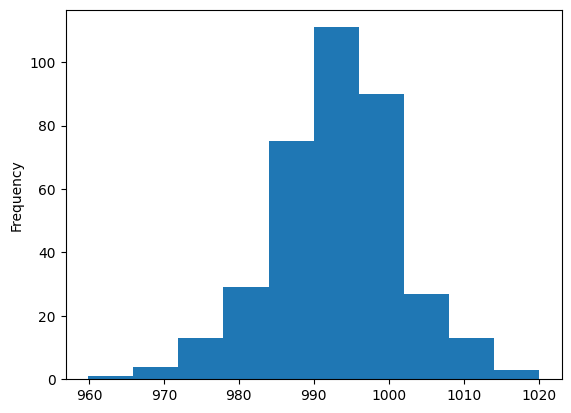

In [845]:
indicadores_diarios['presion_atmosferica'].plot.hist()

<Axes: ylabel='Frequency'>

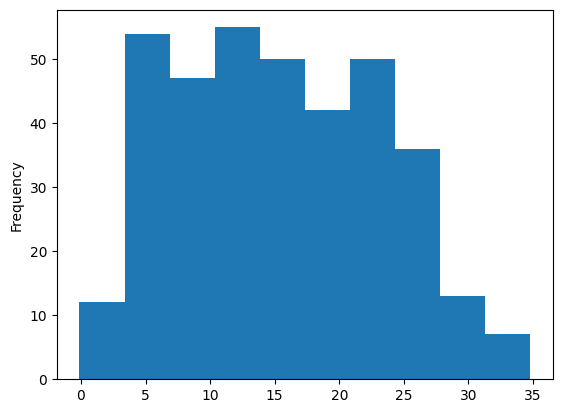

In [846]:
indicadores_diarios['temperatura_celsius'].plot.hist()

<Axes: ylabel='Frequency'>

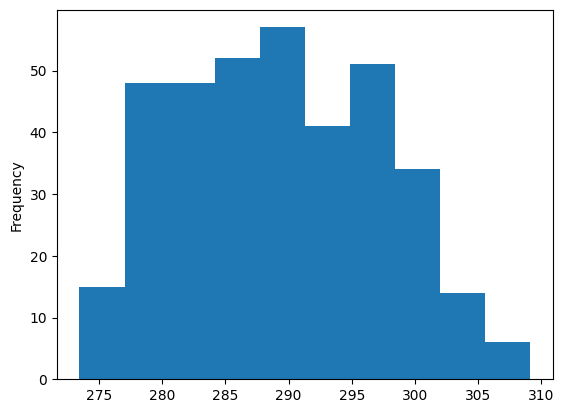

In [847]:
indicadores_diarios['temperatura_kelvin'].plot.hist()

<Axes: ylabel='Frequency'>

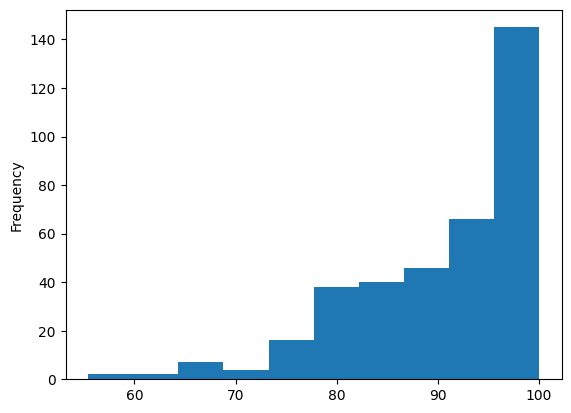

In [848]:
indicadores_diarios['humedad_relativa'].plot.hist()

<Axes: ylabel='Frequency'>

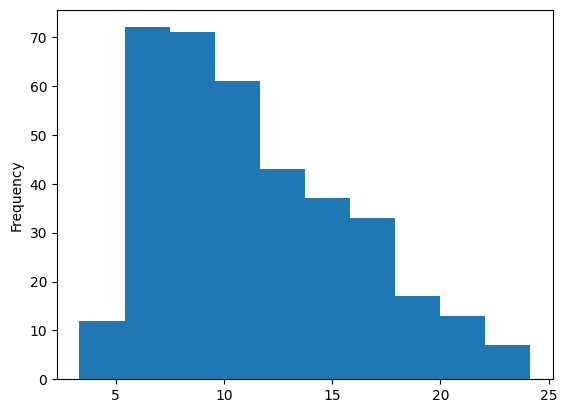

In [849]:
indicadores_diarios['presion_vapor'].plot.hist()

<Axes: ylabel='Frequency'>

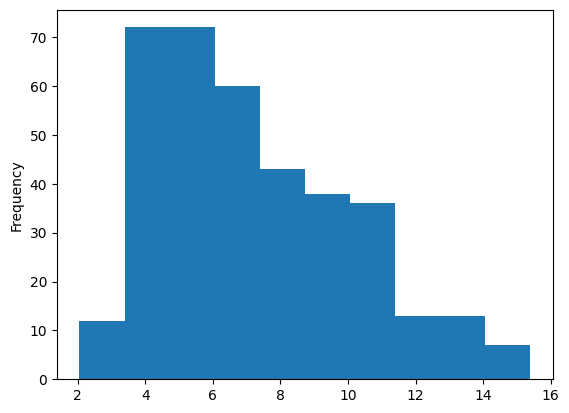

In [850]:
indicadores_diarios['humedad_especifica'].plot.hist()

<Axes: ylabel='Frequency'>

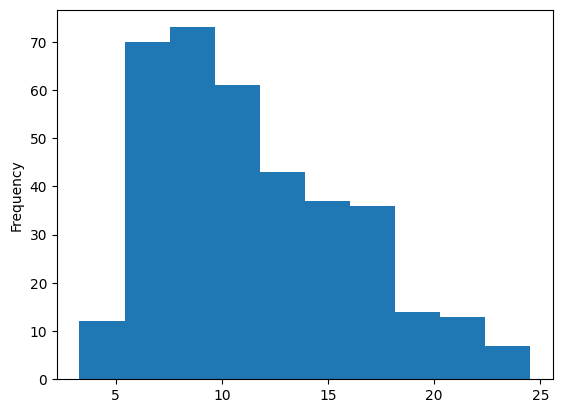

In [851]:
indicadores_diarios['concentracion_vapor'].plot.hist()

<Axes: ylabel='Frequency'>

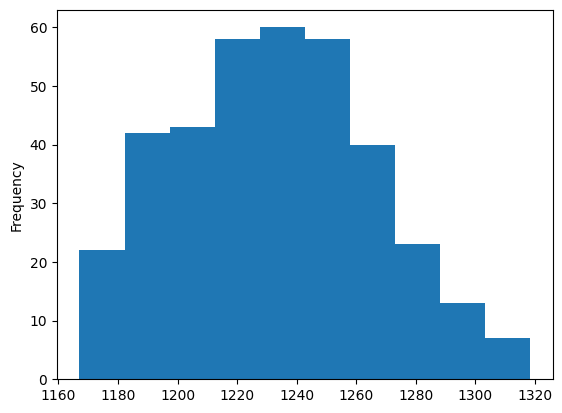

In [852]:
indicadores_diarios['densidad_aire'].plot.hist()

<Axes: ylabel='Frequency'>

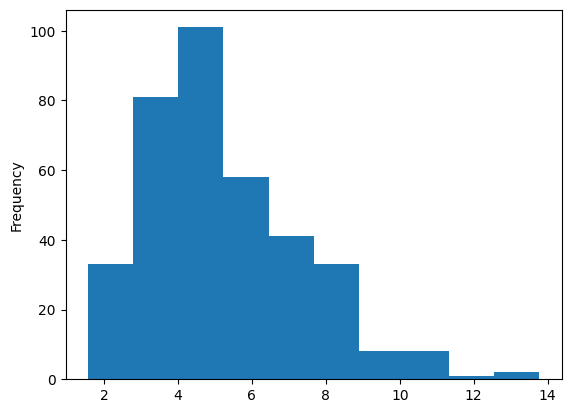

In [853]:
indicadores_diarios['velocidad_viento'].plot.hist()

<Axes: ylabel='Frequency'>

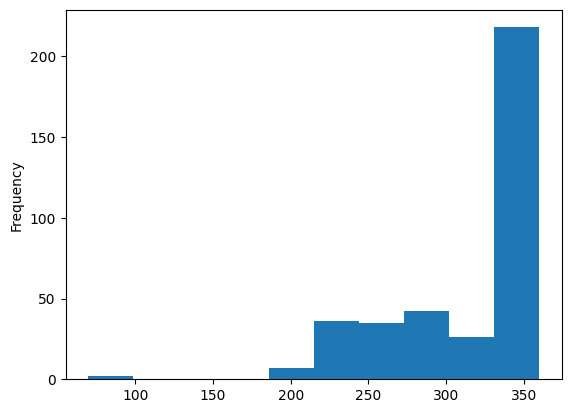

In [854]:
indicadores_diarios['direccion_viento'].plot.hist()

<Axes: ylabel='Frequency'>

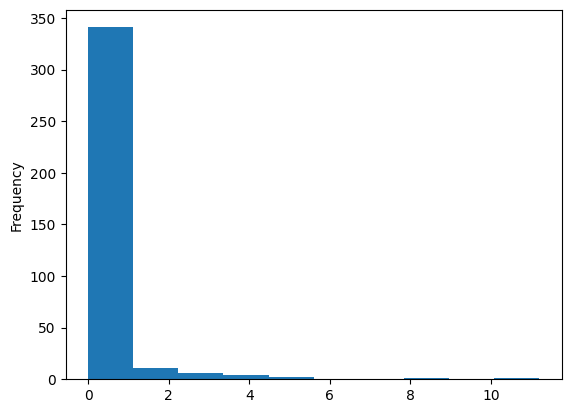

In [855]:
indicadores_diarios['precipitacion_total'].plot.hist()

<Axes: ylabel='Frequency'>

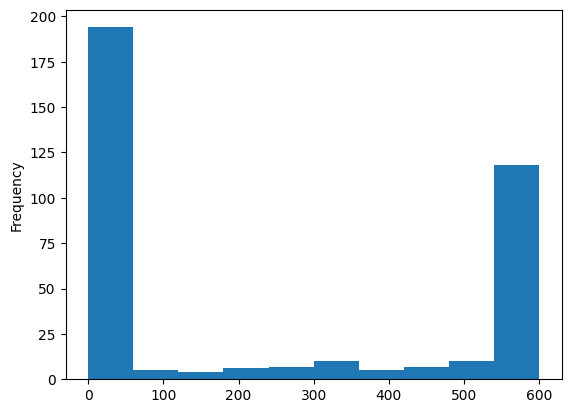

In [856]:
indicadores_diarios['duracion_lluvia'].plot.hist()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [857]:
# crear una columna de mes
# comprobar que mes es index
indicadores_diarios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 2020-01-01 to 2020-12-31
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   presion_atmosferica  366 non-null    float64
 1   temperatura_celsius  366 non-null    float64
 2   temperatura_kelvin   366 non-null    float64
 3   humedad_relativa     366 non-null    float64
 4   presion_vapor        366 non-null    float64
 5   humedad_especifica   366 non-null    float64
 6   concentracion_vapor  366 non-null    float64
 7   densidad_aire        366 non-null    float64
 8   velocidad_viento     366 non-null    float64
 9   direccion_viento     366 non-null    float64
 10  precipitacion_total  366 non-null    float64
 11  duracion_lluvia      366 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 45.3+ KB


In [858]:
# me aseguro que el index sea datetime para extraer el mes
fecha_index = pd.to_datetime(indicadores_diarios.index)

In [859]:
# extraer el mes del index
indicadores_diarios['mes'] = fecha_index.month

In [860]:
# agrupacion y promedio mensual
promedios_mensuales = indicadores_diarios.groupby('mes').mean()

In [861]:
# eliminar columnas indicadas
promedios_mensuales.drop(columns = ['presion_atmosferica', 'temperatura_kelvin', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia'], inplace = True)

In [862]:
# tabla resultado
promedios_mensuales

,temperatura_celsius,humedad_relativa,velocidad_viento
mes,,,
1,10.369355,89.117097,5.286129
2,11.839655,88.497586,6.760345
3,11.842258,85.695484,5.708065
4,15.883000,84.595000,5.403000
5,16.270000,88.799355,4.896774
6,20.031667,92.504000,5.087667
7,21.082258,86.870968,4.262903
8,21.332581,93.273871,4.885484
9,19.773333,94.503333,4.812000


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [863]:
# creacion con funcion pivot table
promedios_mensuales_pivot_table = indicadores_diarios.pivot_table(index = 'mes', values = ['humedad_relativa', 'temperatura_celsius', 'velocidad_viento'], aggfunc = 'mean')

In [864]:
# tabla resultado
promedios_mensuales_pivot_table

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
1,89.117097,10.369355,5.286129
2,88.497586,11.839655,6.760345
3,85.695484,11.842258,5.708065
4,84.595000,15.883000,5.403000
5,88.799355,16.270000,4.896774
6,92.504000,20.031667,5.087667
7,86.870968,21.082258,4.262903
8,93.273871,21.332581,4.885484
9,94.503333,19.773333,4.812000


In [865]:
# nueva columna con formula
# temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4
promedios_mensuales_pivot_table['indice_calor'] = promedios_mensuales_pivot_table['temperatura_celsius'] + 0.33 * promedios_mensuales_pivot_table['humedad_relativa'] - 0.7 * promedios_mensuales_pivot_table['velocidad_viento'] - 4

In [866]:
promedios_mensuales_pivot_table

,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
1,89.117097,10.369355,5.286129,32.077706
2,88.497586,11.839655,6.760345,32.311617
3,85.695484,11.842258,5.708065,32.126123
4,84.595000,15.883000,5.403000,36.017250
5,88.799355,16.270000,4.896774,38.146045
6,92.504000,20.031667,5.087667,42.996620
7,86.870968,21.082258,4.262903,42.765645
8,93.273871,21.332581,4.885484,44.693119
9,94.503333,19.773333,4.812000,43.591033


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [867]:
# convertir tabla anterior a formato largo con melt()
tabla_melt = promedios_mensuales_pivot_table.melt()

In [868]:
tabla_melt

,variable,value
0,humedad_relativa,89.117097
1,humedad_relativa,88.497586
2,humedad_relativa,85.695484
3,humedad_relativa,84.595000
4,humedad_relativa,88.799355
5,humedad_relativa,92.504000
6,humedad_relativa,86.870968
7,humedad_relativa,93.273871
8,humedad_relativa,94.503333
9,humedad_relativa,95.853871


In [869]:
# convertir tabla anterior a formato largo con stack()
tabla_stack = promedios_mensuales_pivot_table.stack()

In [870]:
tabla_stack

mes                     
1    humedad_relativa       89.117097
     temperatura_celsius    10.369355
     velocidad_viento        5.286129
     indice_calor           32.077706
2    humedad_relativa       88.497586
     temperatura_celsius    11.839655
     velocidad_viento        6.760345
     indice_calor           32.311617
3    humedad_relativa       85.695484
     temperatura_celsius    11.842258
     velocidad_viento        5.708065
     indice_calor           32.126123
4    humedad_relativa       84.595000
     temperatura_celsius    15.883000
     velocidad_viento        5.403000
     indice_calor           36.017250
5    humedad_relativa       88.799355
     temperatura_celsius    16.270000
     velocidad_viento        4.896774
     indice_calor           38.146045
6    humedad_relativa       92.504000
     temperatura_celsius    20.031667
     velocidad_viento        5.087667
     indice_calor           42.996620
7    humedad_relativa       86.870968
     temperatura_celsius    21.082258
     velocidad_viento        4.262903
     indice_calor           42.765645
8    humedad_relativa       93.273871
     temperatura_celsius    21.332581
     velocidad_viento        4.885484
     indice_calor           44.693119
9    humedad_relativa       94.503333
     temperatura_celsius    19.773333
     velocidad_viento        4.812000
     indice_calor           43.591033
10   humedad_relativa       95.853871
     temperatura_celsius    14.087097
     velocidad_viento        5.647097
     indice_calor           37.765906
11   humedad_relativa       94.883333
     temperatura_celsius    11.062000
     velocidad_viento        4.799000
     indice_calor           35.014200
12   humedad_relativa       95.985161
     temperatura_celsius    10.499355
     velocidad_viento        5.462903
     indice_calor           34.350426
dtype: float64

Al usar melt () la tabla muestra los valores del mes 1 al 12, por cada variable sin agruparlos. En cambio con la función stack() la tabla va agrupando los valores de las variables por cada mes.